## A brief primer


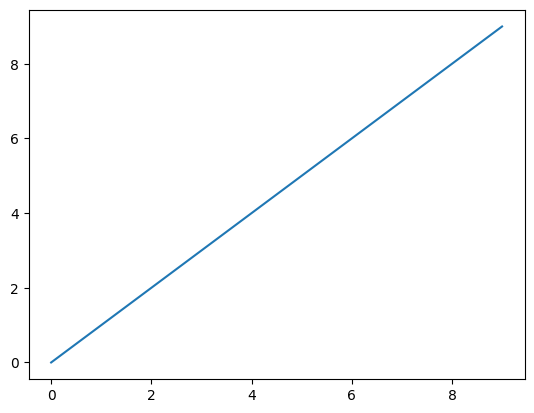

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = np.arange(10)
plt.plot(data)

### Figures and subplots


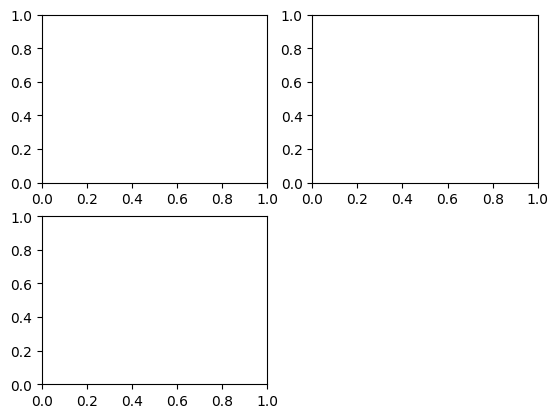

In [2]:
fig = plt.figure()  # plots reside within this
# can't plot a figure with no plots - adding a subplot to it:
ax1 = fig.add_subplot(2, 2, 1)  # dividing the figure into 2x2 spaces and selecting the first one
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
# ax3 = fig.add_subplot(3, 3, 3) # makes a division on the original figure - places over the 2x2 one

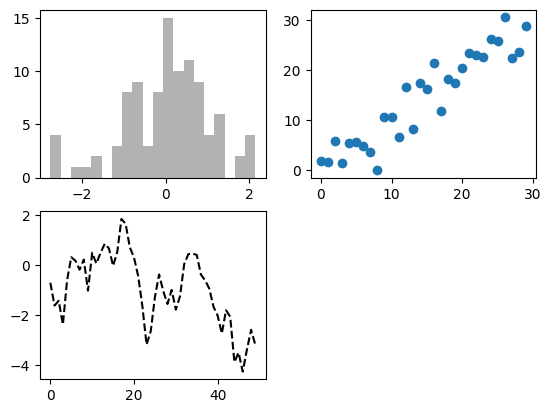

In [5]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

# adding data to the plots:
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

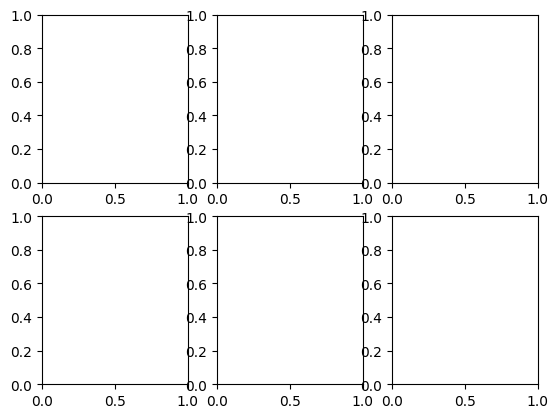

In [6]:
# a more practical way of creating subplots:
fig, axes = plt.subplots(2, 3)
axes

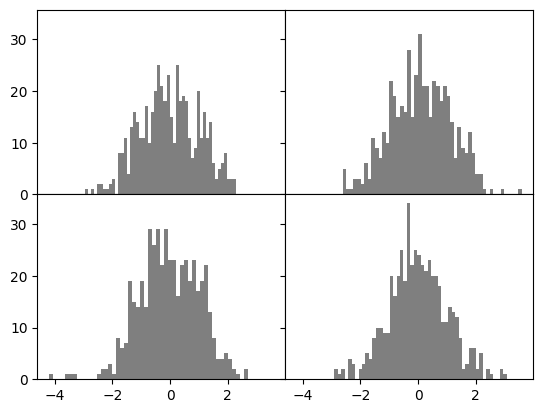

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i][j].hist(np.random.standard_normal(500), bins=50, color="black", alpha=0.5)
fig.subplots_adjust(wspace=0, hspace=0)

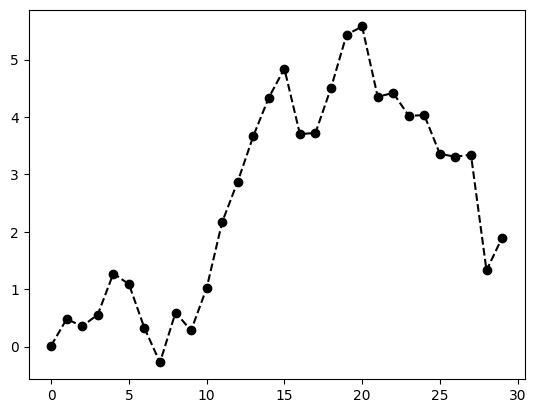

In [10]:
# adding markers to the points in a line plot:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color="black", linestyle="--", marker="o")

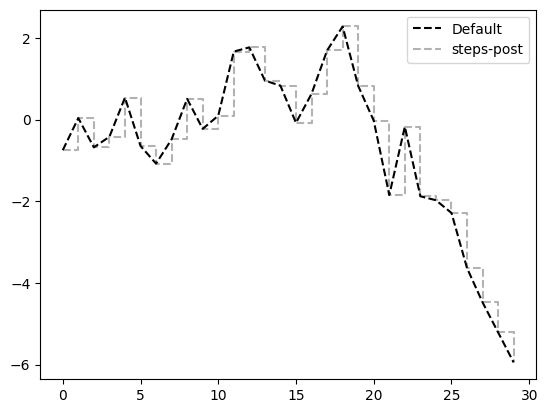

In [14]:
# creating a different drawstyle and adding labels:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()

ax.plot(data, color="black", linestyle="--", label="Default")  # curve 1
ax.plot(data, color="black", alpha=0.3, linestyle="dashed", drawstyle="steps-post", label="steps-post")  # curve 2

ax.legend()  # add labels to the figure - gotta pass 'label' argument to the plots for this to work

### Ticks, labels and legends

Plot decorations can be accessed through methods in the `plt` object. Examples: `xlim`, `xticks`, `xticklabels`.

They can be called in two ways, and will affect the most recently created `AxesSubplot`:

- `plt.xlim()`: returns the current value;
- `plt.xlim([0, 10])`: sets to the given value.

You can also call them using `ax.get_xlim()`, `ax.set_xlim()` and so on.


array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200.])

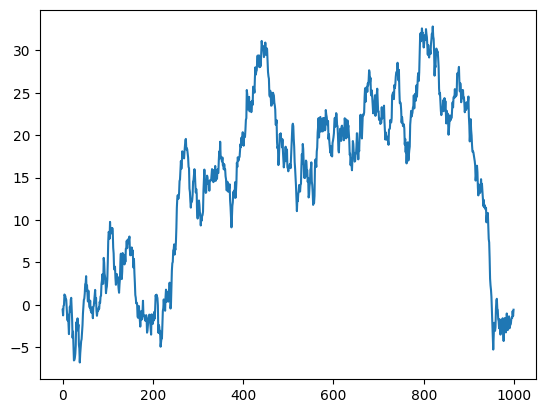

In [ ]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum())
ax.get_xticks()  # same as plt.xticks()

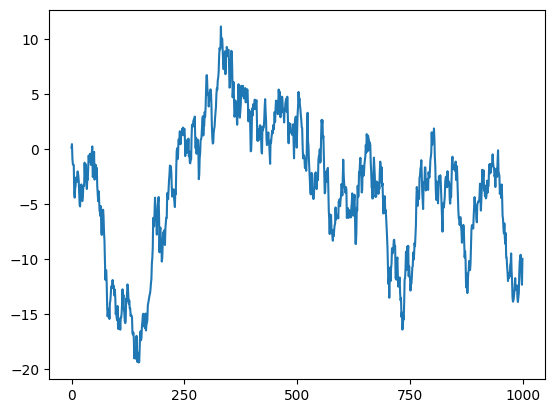

In [ ]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum())
ax.set_xticks(np.linspace(0, 1000, 5))

([<matplotlib.axis.XTick at 0x1a3d862b4f0>,
 [Text(0.0, 0, '0'),
  Text(250.0, 0, '250'),
  Text(500.0, 0, '500'),
  Text(750.0, 0, '750'),
  Text(1000.0, 0, '1000')])

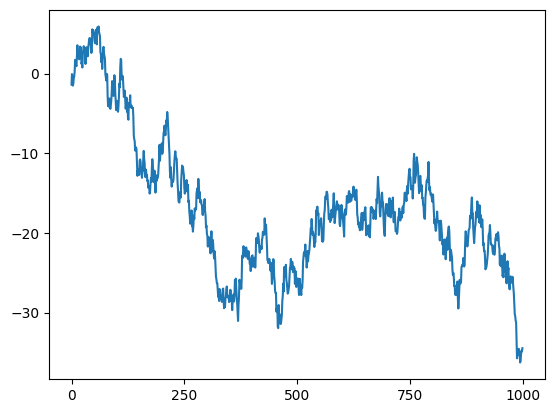

In [21]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum())
plt.xticks(np.linspace(0, 1000, 5))

C:\Users\biels\AppData\Local\Temp\ipykernel_9640\3014615842.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel="Y axis label from set()", yticklabels=["x", "y", "z", "w"])


[Text(0, 0.5, 'Y axis label from set()'),
 [Text(0, -15.0, 'x'),
  Text(0, -10.0, 'y'),
  Text(0, -5.0, 'z'),
  Text(0, 0.0, 'w'),
  Text(0, 5.0, ''),
  Text(0, 10.0, ''),
  Text(0, 15.0, ''),
  Text(0, 20.0, ''),
  Text(0, 25.0, ''),
  Text(0, 30.0, '')]]

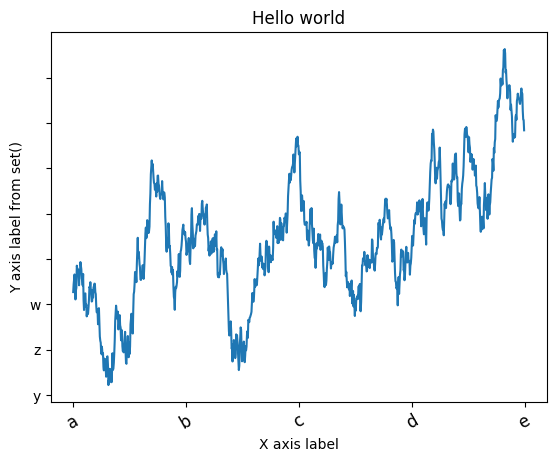

In [26]:
# a few other decorators:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ax.set_xticks(np.linspace(0, 1000, 5))
ax.set_xticklabels(list("abcde"), rotation=30, fontsize=12)
ax.set_xlabel("X axis label")
ax.set_title("Hello world")

# can also call in a single function call:
ax.set(ylabel="Y axis label from set()", yticklabels=["x", "y", "z", "w"])

### Annotations and drawing on a subplot


Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

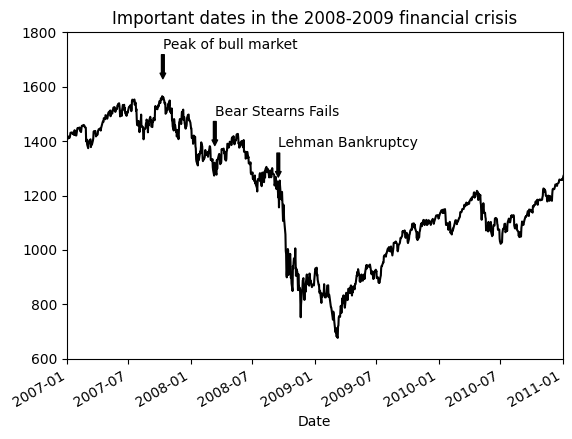

In [27]:
from datetime import datetime

fig, ax = plt.subplots()

data = pd.read_csv("examples/spx.csv", index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy"),
]

for date, label in crisis_data:
    ax.annotate(
        label,
        xy=(date, spx.asof(date) + 75),
        xytext=(date, spx.asof(date) + 225),
        arrowprops=dict(facecolor="black", headwidth=4, width=2, headlength=4),
        horizontalalignment="left",
        verticalalignment="top",
    )

# crop only the interesting part of the curve:
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008-2009 financial crisis")

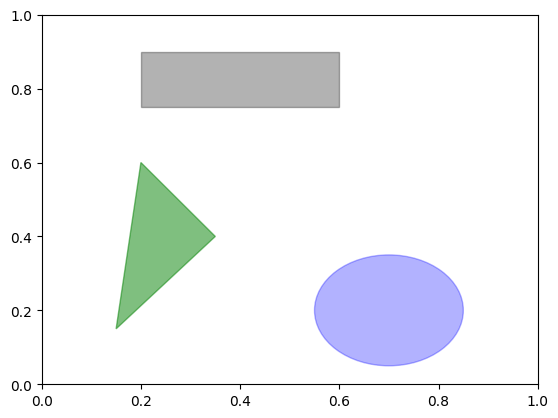

In [ ]:
# some other shapes:
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]], color="green", alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving plots to file


In [ ]:
fig.savefig("figpath.png", dpi=400)

In [30]:
import os

os.remove("figpath.png")

### matplotlib configuration (`plt.rc` object)


In [ ]:
# change the global default figure size:
plt.rc("figure", figsize=(10, 10))
plt.rcdefaults()  # restore defaults

plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

## Plotting with pandas and seaborn


<Axes: >

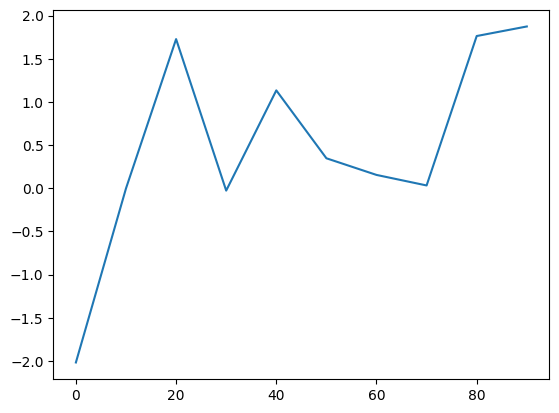

In [ ]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()  # can receive an ax object where the plot should be placed on

<Axes: >

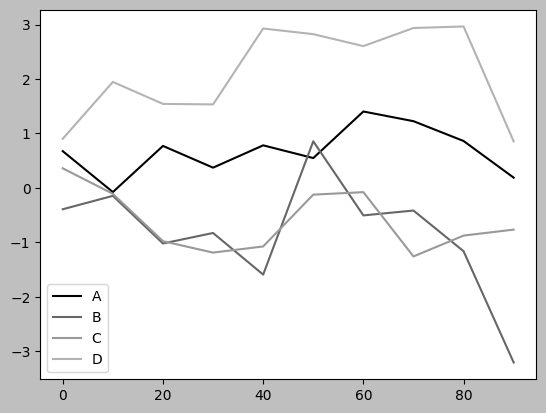

In [ ]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0), columns=list("ABCD"), index=np.arange(0, 100, 10))

plt.style.use("grayscale")
df.plot()  # equivalent to df.plot.line()

<Axes: >

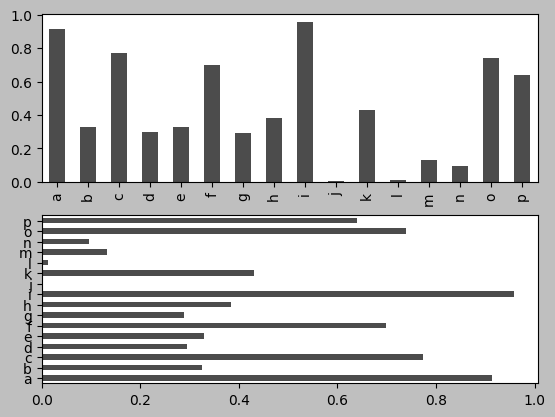

In [35]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

In [36]:
# bar plot in a dataframe - columns are grouped together:
df = pd.DataFrame(
    np.random.uniform(size=(6, 4)),
    index=["one", "two", "three", "four", "five", "six"],
    columns=pd.Index(["A", "B", "C", "D"], name="Genus"),
)

df

Genus,A,B,C,D
one,0.293907,0.263572,0.042241,0.796944
two,0.732630,0.840692,0.013930,0.927310
three,0.228874,0.312452,0.675307,0.494190
four,0.192651,0.042013,0.932940,0.991627
five,0.623886,0.888767,0.280877,0.581295
six,0.399058,0.568358,0.588721,0.304990


<Axes: >

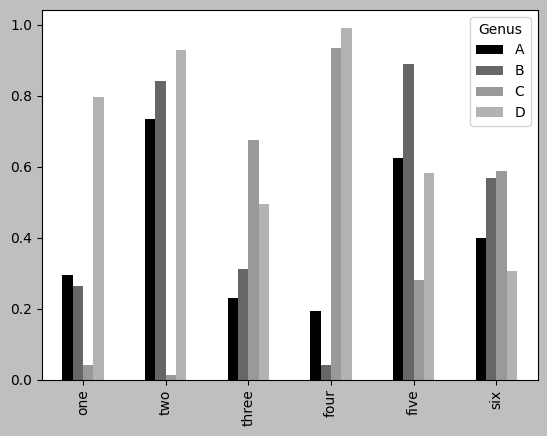

In [37]:
df.plot.bar()

<Axes: >

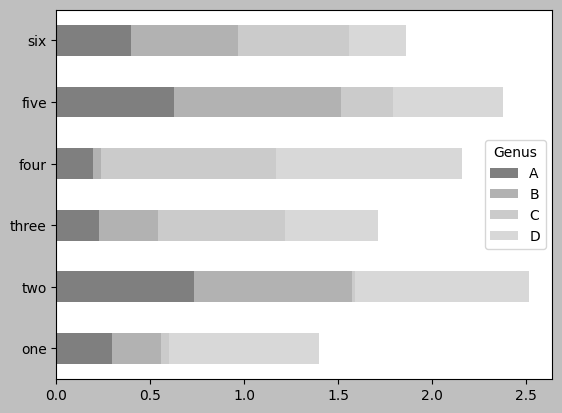

In [38]:
df.plot.barh(stacked=True, alpha=0.5)

<Axes: >

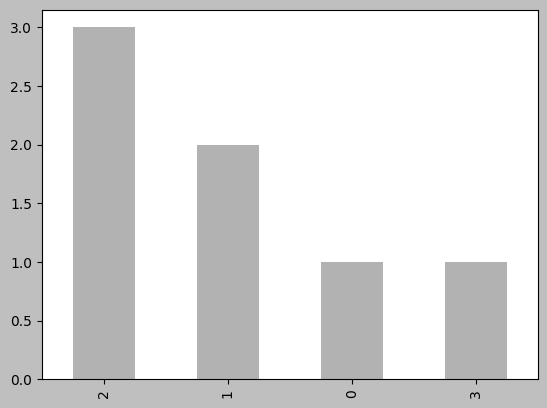

In [40]:
# visualizing a serie's value frequency:
s = pd.Series([0, 1, 1, 2, 2, 2, 3])
s.value_counts().plot.bar(color="black", alpha=0.3)

In [43]:
# analyzing restaurant tipping:
tips = pd.read_csv("examples/tips.csv")
tips.sample(5)

,total_bill,tip,smoker,day,time,size
11,35.26,5.00,No,Sun,Dinner,4
129,22.82,2.18,No,Thur,Lunch,3
25,17.81,2.34,No,Sat,Dinner,4
93,16.32,4.30,Yes,Fri,Dinner,2
65,20.08,3.15,No,Sat,Dinner,3


In [45]:
party_counts = pd.crosstab(tips["day"], tips["size"])  # frequency of party sizes in each day of the week
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [ ]:
# sort by days of the week and remove 1 and 6-person parties
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"], columns=[2, 3, 4, 5])
party_counts

size,2,3,4,5
day,,,,
Thur,48,4,5,1
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3


In [ ]:
# normalize so that each row sums to 1:
party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

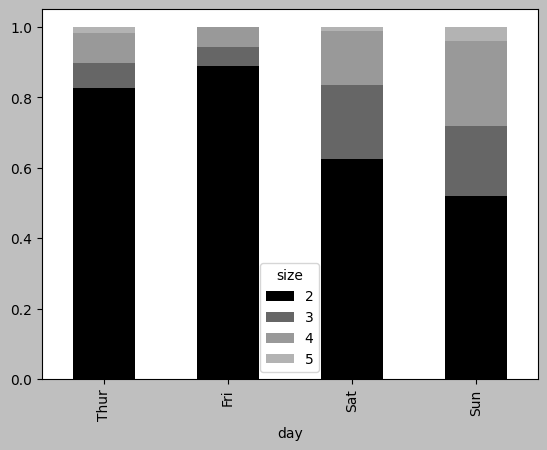

In [51]:
party_pcts.plot.bar(stacked=True)  # we can see that party sizes increase on the weekend

In [56]:
party_counts * party_counts.columns

size,2,3,4,5
day,,,,
Thur,96,12,20,5
Fri,32,3,4,0
Sat,106,54,52,5
Sun,78,45,72,15


<Axes: xlabel='day'>

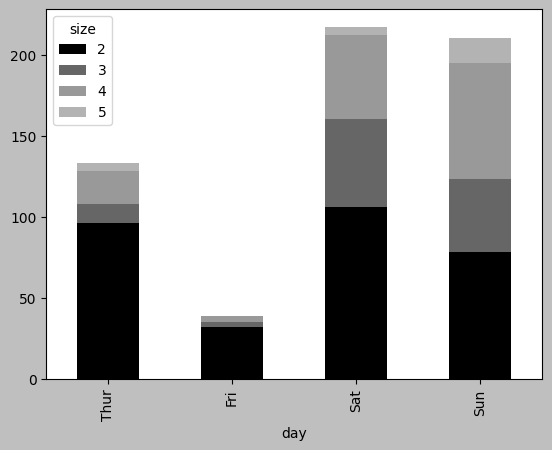

In [55]:
# amount of people with labeled party sizes for each day
(party_counts * party_counts.columns).plot.bar(stacked=True)

In [ ]:
import seaborn as sns

# tipping percentage by day
tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

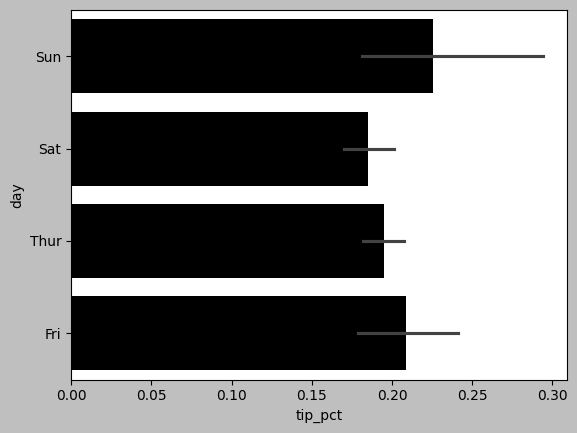

In [ ]:
# bar is the average, line is the 95% confidence interval
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")

<Axes: xlabel='tip_pct', ylabel='day'>

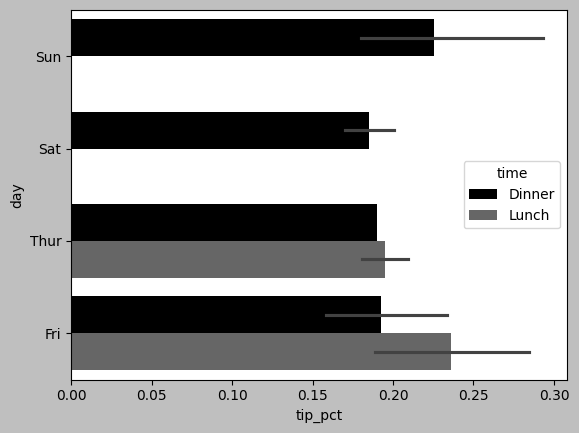

In [59]:
# split by additional categorical value:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

<Axes: ylabel='Frequency'>

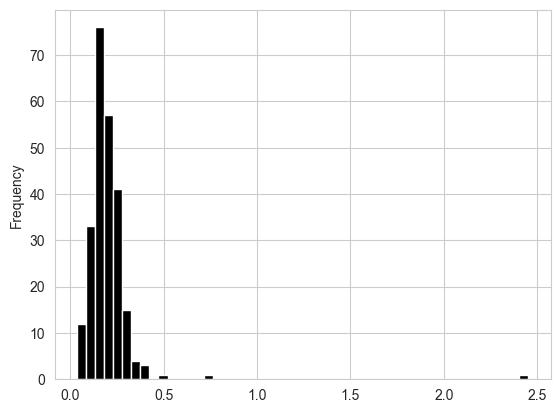

In [ ]:
# change style:
sns.set_style("whitegrid")

# histogram:
tips["tip_pct"].plot.hist(bins=50)

<Axes: ylabel='Density'>

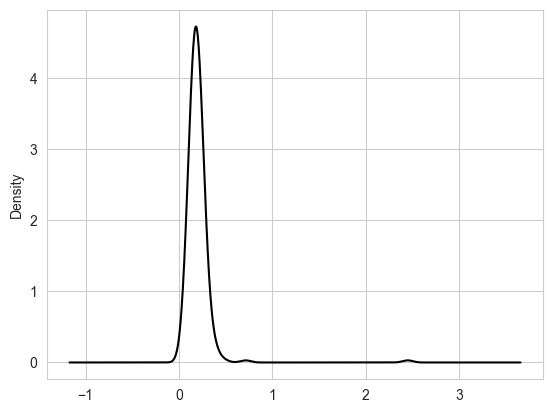

In [ ]:
# density plot (KDE):
tips["tip_pct"].plot.density()

<Axes: ylabel='Count'>

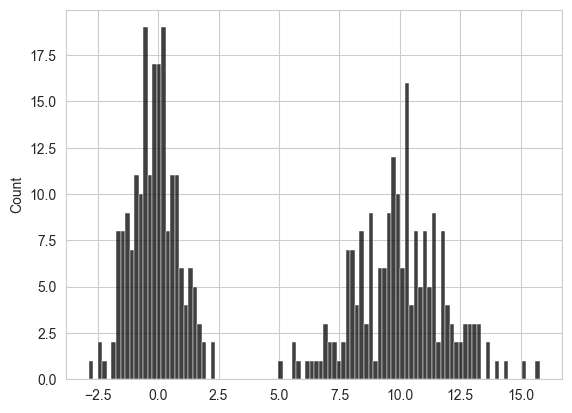

In [ ]:
# with seaborn:
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)

values = pd.Series(np.concatenate([comp1, comp2]))
sns.histplot(values, bins=100, color="black")

In [ ]:
# scatter (point) plots:
macro = pd.read_csv("examples/macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]

trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

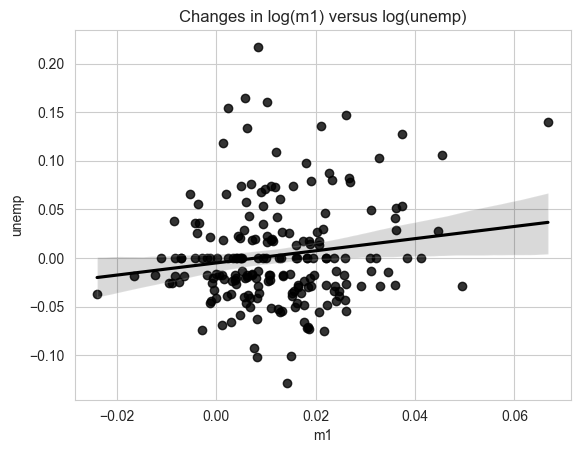

In [ ]:
# scatter plot + linear regression line
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)")

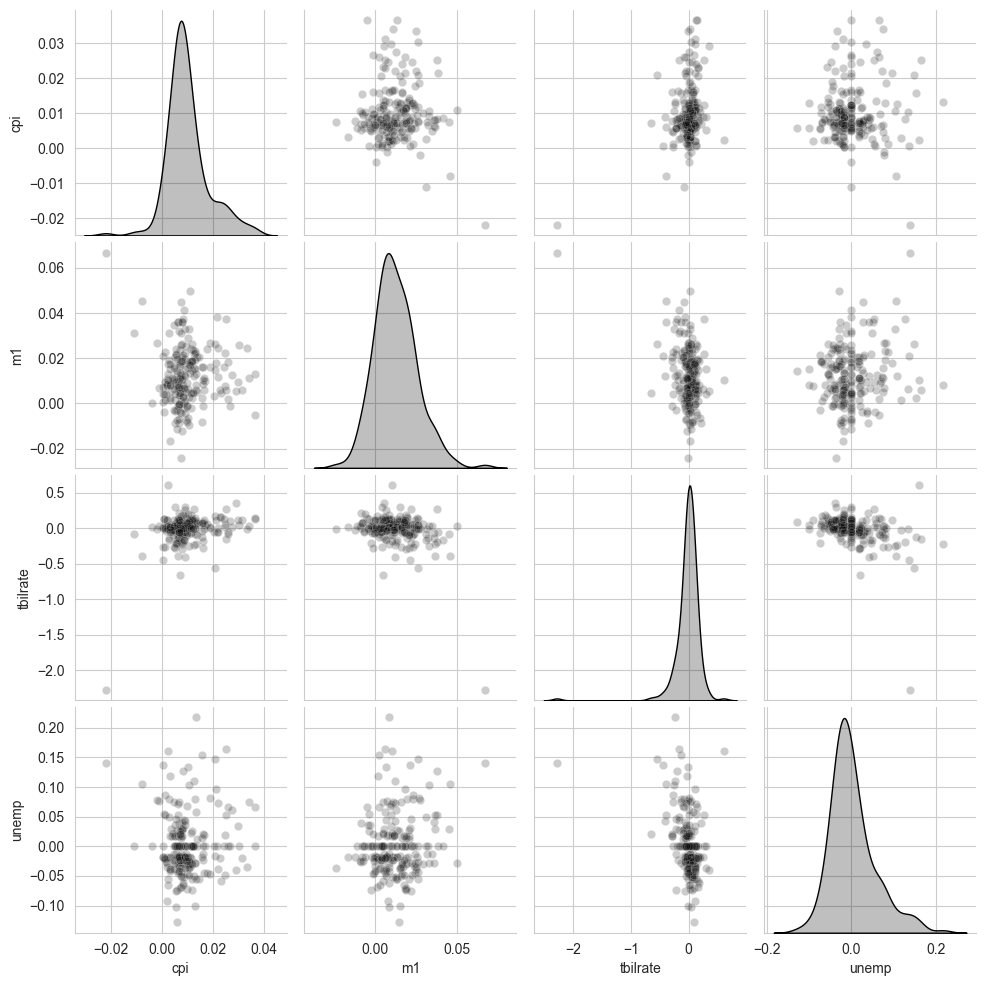

In [ ]:
# pairs plot or scatter plot matrix - diagonal has histograms/density estimates
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

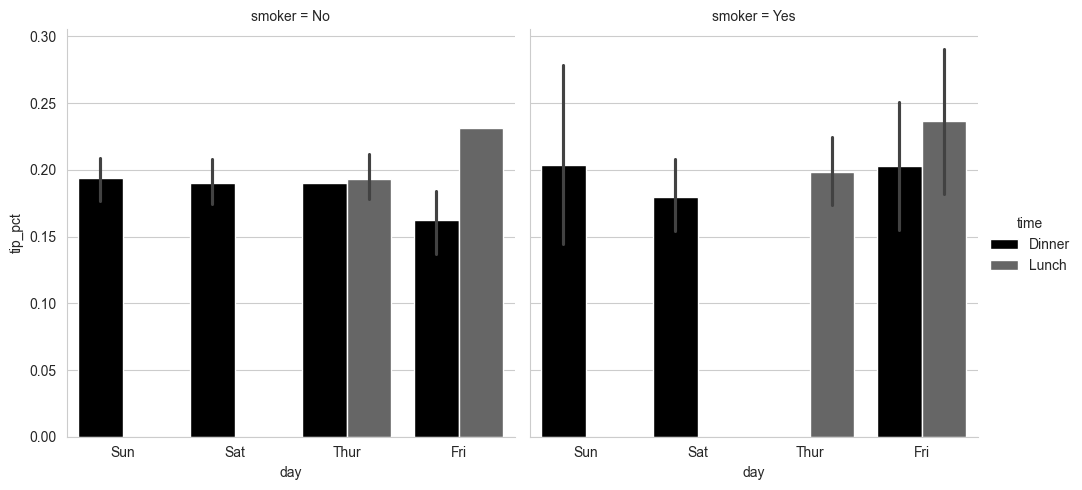

In [ ]:
# facet grids and categorical data
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker", kind="bar", data=tips[tips.tip_pct < 1])

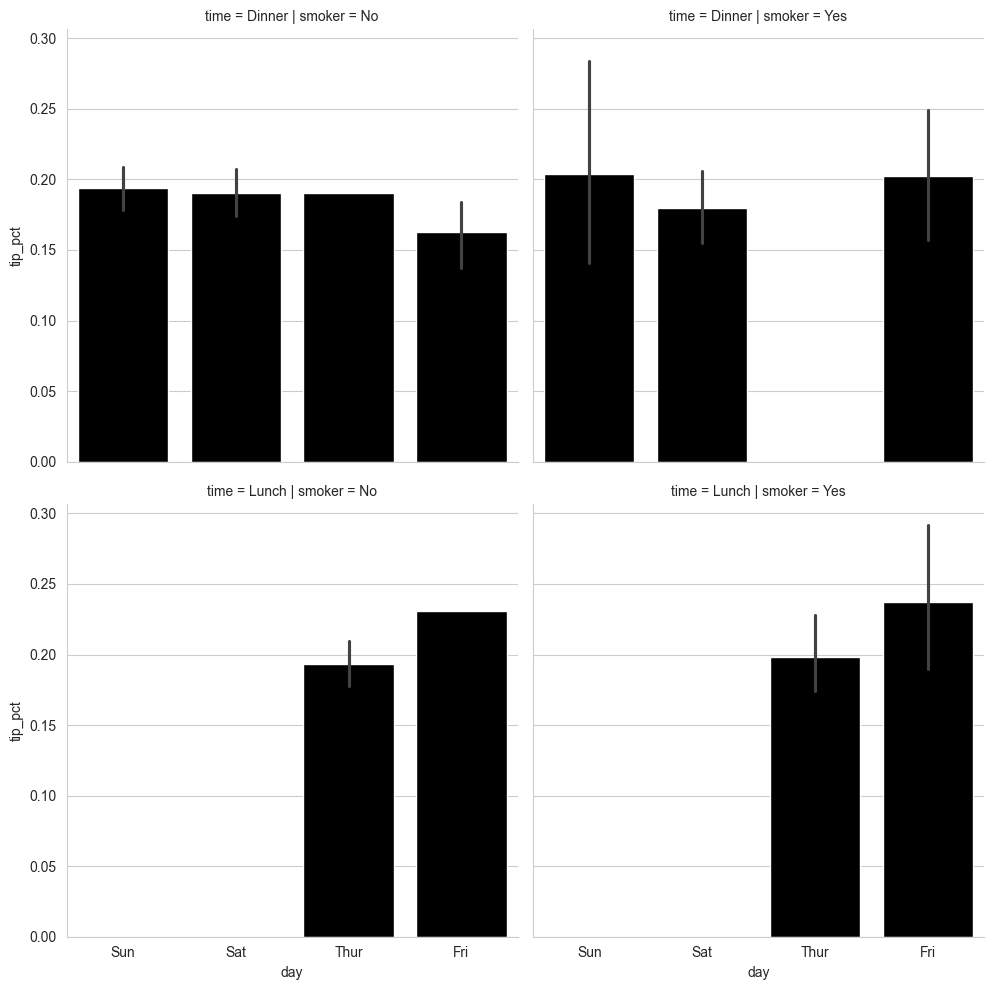

In [ ]:
# adding one row for each time value:
sns.catplot(x="day", y="tip_pct", row="time", col="smoker", kind="bar", data=tips[tips.tip_pct < 1])

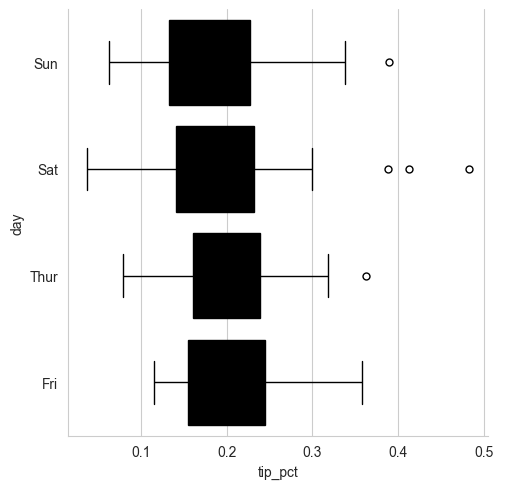

In [ ]:
# box plots:
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5])